# Multi-Class Pneumonia Classification using EfficientNet-B0 with Explainable AI (Grad-CAM)

## Notebook 02: Dataset Preparation

### Objectives

This notebook prepares the original Chest X-ray dataset for multi-class pneumonia classification.

The main objectives are:

- Load the original Chest X-ray dataset
- Separate bacterial and viral pneumonia images
- Merge all dataset splits
- Perform a stratified 70/15/15 train-validation-test split
- Create the processed dataset
- Verify the processed dataset

## Import Required Libraries

In [1]:
# ============================================================
# Import Required Libraries
# ============================================================

import os
import shutil
import random
from pathlib import Path

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

sns.set_theme(style="whitegrid", context="notebook")

print("✅ Libraries imported successfully.")

✅ Libraries imported successfully.


## Reproducibility

Set a fixed random seed to ensure reproducible dataset preparation.

In [2]:
# ============================================================
# Set Random Seed
# ============================================================

SEED = 42

random.seed(SEED)
np.random.seed(SEED)

print(f"Random Seed : {SEED}")

Random Seed : 42


## Dataset Paths

Define the original dataset location and the destination directory for the processed dataset.

In [3]:
# ============================================================
# Dataset Paths
# ============================================================

ORIGINAL_DATASET = Path(
    "/mnt/g/Research paper/Research paper/dataset of pneomunia/chest_xray"
)

PROCESSED_DATASET = Path(
    "/mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI/dataset/processed_dataset"
)

print("Original Dataset")
print(ORIGINAL_DATASET)

print("\nProcessed Dataset")
print(PROCESSED_DATASET)

Original Dataset
/mnt/g/Research paper/Research paper/dataset of pneomunia/chest_xray

Processed Dataset
/mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI/dataset/processed_dataset


## Create Processed Dataset Directory

Create the destination directory if it does not already exist.

In [4]:
# ============================================================
# Create Processed Dataset Directory
# ============================================================

PROCESSED_DATASET.mkdir(
    parents=True,
    exist_ok=True
)

print("Processed dataset directory is ready.")
print(PROCESSED_DATASET)

Processed dataset directory is ready.
/mnt/g/Research paper/Research paper/Pneumonia-EfficientNetB0-XAI/dataset/processed_dataset


## Build Dataset Metadata

Collect all images from the original dataset and create a metadata table containing:

- Image path
- Original dataset split
- Multi-class label (NORMAL, BACTERIA, VIRUS)

The metadata will be used for stratified dataset splitting.

In [5]:
# ============================================================
# Build Dataset Metadata
# ============================================================

records = []

IMAGE_EXTENSIONS = {".jpg", ".jpeg", ".png"}

original_splits = ["train", "val", "test"]

for split in original_splits:

    split_path = ORIGINAL_DATASET / split

    for class_dir in split_path.iterdir():

        if not class_dir.is_dir():
            continue

        original_class = class_dir.name

        for image_path in class_dir.iterdir():

            if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue

            filename = image_path.name.lower()

            # ---------- Multi-Class Label ----------

            if original_class == "NORMAL":
                label = "NORMAL"

            elif "bacteria" in filename:
                label = "BACTERIA"

            elif "virus" in filename:
                label = "VIRUS"

            else:
                continue

            records.append({
                "image_path": image_path,
                "filename": image_path.name,
                "original_split": split,
                "label": label
            })

print(f"Total Images Collected : {len(records):,}")

Total Images Collected : 5,856


## Create Metadata DataFrame

Convert the collected image information into a Pandas DataFrame for further processing.

In [6]:
# ============================================================
# Create Metadata DataFrame
# ============================================================

metadata = pd.DataFrame(records)

print(metadata.shape)

metadata.head()

(5856, 4)


,image_path,filename,original_split,label
0,/mnt/g/Research paper/Research paper/dataset o...,IM-0115-0001.jpeg,train,NORMAL
1,/mnt/g/Research paper/Research paper/dataset o...,IM-0117-0001.jpeg,train,NORMAL
2,/mnt/g/Research paper/Research paper/dataset o...,IM-0119-0001.jpeg,train,NORMAL
3,/mnt/g/Research paper/Research paper/dataset o...,IM-0122-0001.jpeg,train,NORMAL
4,/mnt/g/Research paper/Research paper/dataset o...,IM-0125-0001.jpeg,train,NORMAL


## Verify Class Distribution

Check the number of images in each class before dataset splitting.

In [8]:
# ============================================================
# Class Distribution
# ============================================================

class_counts = (
    metadata["label"]
    .value_counts()
    .sort_index()
)

display(class_counts)

label
BACTERIA    2780
NORMAL      1583
VIRUS       1493
Name: count, dtype: int64

## Visualize Class Distribution

Visualize the number of images in each class.

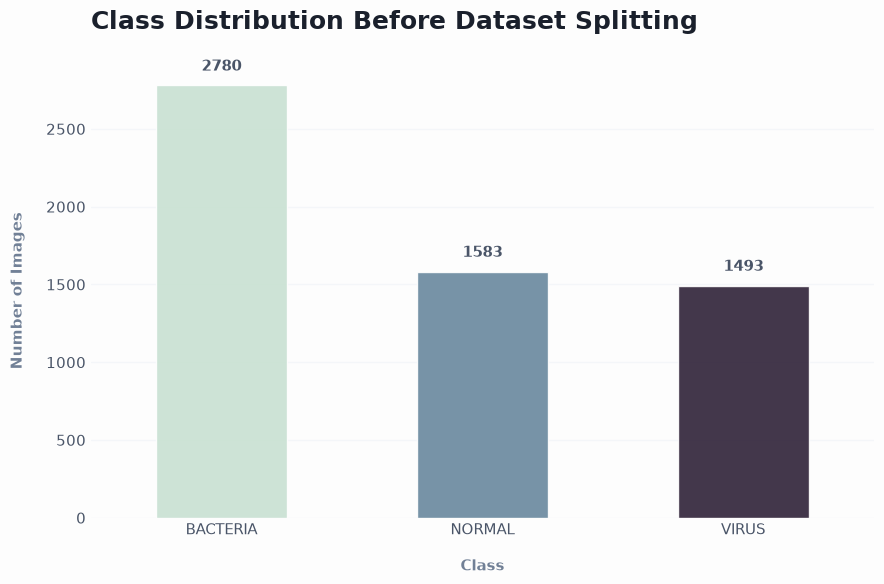

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Silence any unnecessary warnings completely
warnings.filterwarnings("ignore", category=FutureWarning)

# Set clean white background
sns.set_theme(style="white")

# Create figure with a crisp layout
fig, ax = plt.subplots(figsize=(9, 6), facecolor="#fdfdfd")
ax.set_facecolor("#fdfdfd")

# Modern soft gradient palette
colors = sns.color_palette("ch:start=.5,rot=-.55", len(class_counts))

# Generate the bar plot (Fixed: added hue and legend=False to fix the warning)
ax = sns.barplot(
    x=class_counts.index,
    y=class_counts.values,
    hue=class_counts.index,
    palette=colors,
    legend=False,
    edgecolor=None,     
    width=0.5,          
    alpha=0.9           
)

# Style and position the bar labels
for container in ax.containers:
    ax.bar_label(
        container, 
        padding=8,      
        fontsize=11, 
        weight="bold",  # Fixed: changed from semibold to bold to prevent font warning
        color="#4a5568" 
    )

# Premium Typography Setup
plt.title(
    "Class Distribution Before Dataset Splitting",
    fontsize=18,
    weight="bold",
    pad=25,
    color="#1a202c",    
    loc="left"          
)

plt.xlabel("Class", fontsize=11, labelpad=15, weight="bold", color="#718096")
plt.ylabel("Number of Images", fontsize=11, labelpad=15, weight="bold", color="#718096")

# Style the axis ticks
plt.xticks(fontsize=11, color="#4a5568")
plt.yticks(fontsize=11, color="#4a5568")

# Remove all outer box borders completely
sns.despine(left=True, bottom=True)

# Add very subtle, clean horizontal lines
ax.yaxis.grid(True, linestyle="-", alpha=0.3, color="#e2e8f0")
ax.xaxis.grid(False)

# Remove the tick marks themselves, keeping just the labels
ax.tick_params(axis='both', which='both', length=0)

# Render cleanly
plt.tight_layout()
plt.show()
